In [47]:
pip install pandas matplotlib

In [2]:
import pandas as pd

df = pd.read_csv("sales.csv")

print(df.head())

        Ship Mode    Segment        Country             City       State  \
0    Second Class   Consumer  United States        Henderson    Kentucky   
1    Second Class   Consumer  United States        Henderson    Kentucky   
2    Second Class  Corporate  United States      Los Angeles  California   
3  Standard Class   Consumer  United States  Fort Lauderdale     Florida   
4  Standard Class   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region         Category Sub-Category     Sales  Quantity  \
0        42420  South        Furniture    Bookcases  261.9600         2   
1        42420  South        Furniture       Chairs  731.9400         3   
2        90036   West  Office Supplies       Labels   14.6200         2   
3        33311  South        Furniture       Tables  957.5775         5   
4        33311  South  Office Supplies      Storage   22.3680         2   

   Discount    Profit  
0      0.00   41.9136  
1      0.00  219.5820  
2      0.00    6.871

In [3]:
print(df.columns)
print(df.shape)

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')
(9994, 13)


In [4]:
################### DATA CLEANING #########   Start ################

In [5]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [6]:
df.dtypes

Ship Mode        object
Segment          object
Country          object
City             object
State            object
Postal Code       int64
Region           object
Category         object
Sub-Category     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

In [7]:
df.duplicated().sum()

17

In [8]:
df = df.drop_duplicates()

In [9]:
print(df.columns)

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')


In [10]:
####    Data Analysis ########### Start

In [11]:
# Sales By Category

In [12]:
category_sales = df.groupby('Category')['Sales'].sum()
print(category_sales)

Category
Furniture          741306.3133
Office Supplies    718735.2440
Technology         836154.0330
Name: Sales, dtype: float64


In [13]:
# profit by category

In [14]:
category_profit = df.groupby('Category')['Profit'].sum()
category_profit

Category
Furniture           18421.8137
Office Supplies    122364.6608
Technology         145454.9481
Name: Profit, dtype: float64

In [15]:
# Sales By Region

In [16]:
region_sales = df.groupby('Region')['Sales'].sum()
region_sales

Region
Central    500782.8528
East       678435.1960
South      391721.9050
West       725255.6365
Name: Sales, dtype: float64

In [17]:
# Top 5 Cities

In [18]:
top_cities = df.groupby('City')['Sales'].sum().sort_values(ascending=False)
top_cities.head()

City
New York City    256319.041
Los Angeles      175831.901
Seattle          119460.282
San Francisco    112577.172
Philadelphia     109061.461
Name: Sales, dtype: float64

In [19]:
# Strongest Region

In [20]:
strong_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
strong_region.head(1)

Region
West    725255.6365
Name: Sales, dtype: float64

In [21]:
# Which category losing profit

In [22]:
category_lost = df.groupby('Category')['Profit'].sum()
category_lost.head(1)

Category
Furniture    18421.8137
Name: Profit, dtype: float64

In [23]:
# Which category is best

In [24]:
category_higest = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
category_higest.head(1)

Category
Technology    145454.9481
Name: Profit, dtype: float64

In [25]:
diff = category_higest.head(1)-category_lost.head(1).sum()
diff    #### this method is worng

Category
Technology    127033.1344
Name: Profit, dtype: float64

In [26]:
## correct method

In [27]:
diff_profit = category_profit['Technology']-category_profit['Furniture']
diff_profit

127033.13440000001

In [28]:
### revenue by region

In [29]:
revenue_region = df.groupby('Region')['Profit'].sum()
revenue_region

Region
Central     39655.8752
East        91506.3092
South       46749.4303
West       108329.8079
Name: Profit, dtype: float64

In [30]:
region_summary = df.groupby('Region').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).sort_values(by='Profit', ascending=False)

region_summary

,Sales,Profit
Region,,
West,725255.6365,108329.8079
East,678435.1960,91506.3092
South,391721.9050,46749.4303
Central,500782.8528,39655.8752


In [31]:
#############  Visualization of data set  ####################

In [32]:
## Task 1: Category Sales Chart

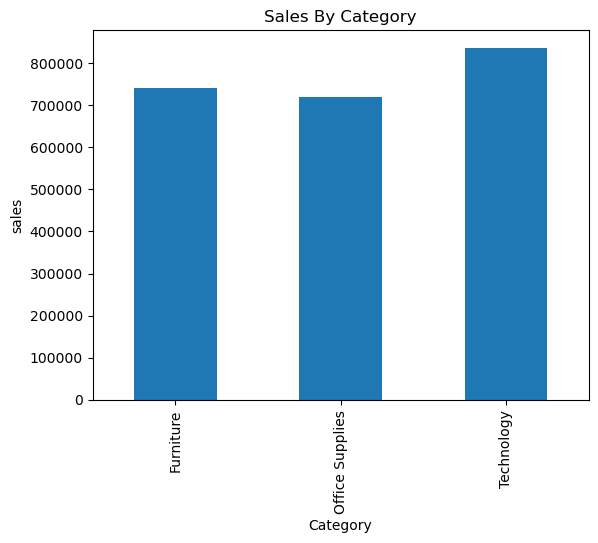

In [33]:
import matplotlib.pyplot as plt

category_sales.plot(kind='bar')
plt.title("Sales By Category")
plt.xlabel("Category")
plt.ylabel("sales")
plt.show()

In [34]:
#### Task 2: Category Profit Chart

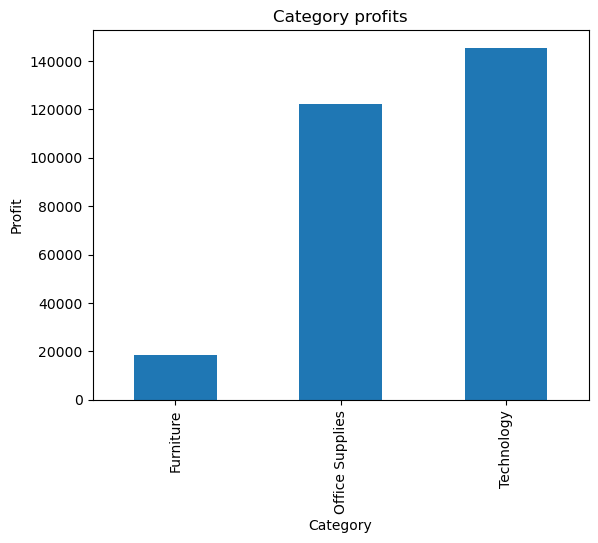

In [35]:
category_profit.plot(kind='bar')
plt.title("Category profits")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

In [36]:
### Region Sales

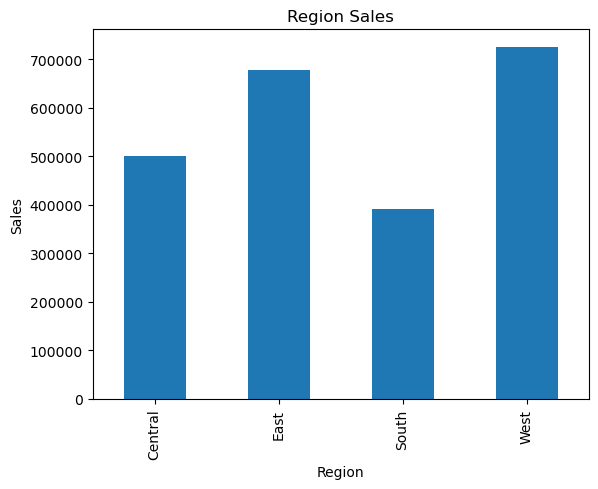

In [37]:
region_sales.plot(kind='bar')
plt.title("Region Sales")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

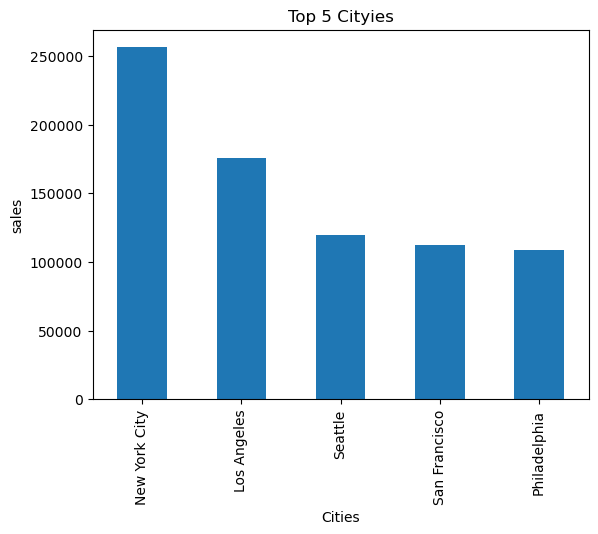

In [38]:
top_cities.sort_values(ascending=False).head().plot(kind='bar')
plt.title("Top 5 Cityies")
plt.xlabel("Cities")
plt.ylabel("sales")
plt.show()

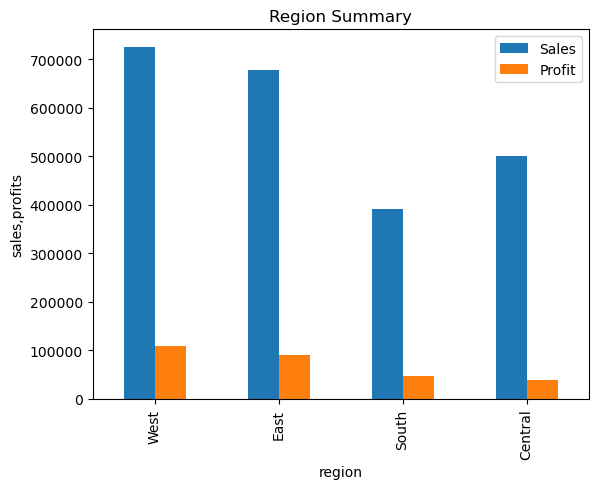

In [39]:
region_summary.plot(kind='bar')
plt.title("Region Summary")
plt.xlabel("region")
plt.ylabel("sales,profits")
plt.show()

In [40]:
summary = f"""
Category Sales:
{category_sales}

Category Profit:
{category_profit}
"""

print(summary)


Category Sales:
Category
Furniture          741306.3133
Office Supplies    718735.2440
Technology         836154.0330
Name: Sales, dtype: float64

Category Profit:
Category
Furniture           18421.8137
Office Supplies    122364.6608
Technology         145454.9481
Name: Profit, dtype: float64



In [41]:
#### Based on the data you provided for "Category Sales" and "Category Profit," here are a few business insights:

### 1. **Technology Category Leading in Sales and Profit:**

* **Sales**: Technology has the highest sales at **836,154.03**, followed by Furniture (**741,306.31**) and Office Supplies (**718,735.24**).
* **Profit**: Similarly, Technology also leads in terms of **profit** with **145,454.95**, followed by Office Supplies (**122,364.66**) and Furniture (**18,421.81**).
* **Insight**: The Technology category not only outperforms in total sales, but also generates the most profit. This suggests strong margins and possibly high demand for tech products, making it a focal point for the business to expand or focus on.

### 2. **Furniture Category Underperforming in Profit:**

* Despite having substantial sales (**741,306.31**), the **Furniture** category generates the lowest profit (**18,421.81**).
* **Insight**: This could indicate high costs associated with furniture (like manufacturing or logistics), low profit margins, or even discounts and promotions that are affecting the overall profit. Analyzing cost structures or finding ways to increase profit margins in this category could be beneficial.

### 3. **Office Supplies: A Balanced Performer:**

* **Sales**: Office Supplies has sales of **718,735.24**, which is the lowest among the three categories.
* **Profit**: However, the **profit** for Office Supplies is significant at **122,364.66**, second only to Technology.
* **Insight**: While Office Supplies may not generate the highest sales volume, its high profit indicates strong margins. This could point to low-cost products with a consistent demand, which might be a sustainable and reliable income source for the business.

### 4. **Opportunities for Strategic Focus:**

* **Growth in Tech**: Given the strong sales and profit in Technology, this category should continue to be a growth area. Expanding the range of products, increasing marketing efforts, or introducing new tech innovations could further drive profitability.
* **Cost Optimization for Furniture**: The low profit in the Furniture category despite decent sales suggests a need to re-evaluate pricing strategies, improve cost efficiencies, or focus on higher-margin furniture items.
* **Leverage Office Supplies' High Margin**: Although sales are lower for Office Supplies, the high profit margin suggests there is potential to enhance sales with targeted campaigns or cross-selling opportunities to customers buying other products.

### 5. **Possible Cross-Selling Opportunities:**

* As you analyze the profitability of each category, there might be opportunities to bundle products. For example, pairing furniture with office supplies or tech could improve overall sales and profit, especially for customers buying items across multiple categories.

### 6. **Re-Evaluation of Sales Channels and Target Markets:**

* Analyzing which channels are driving sales in each category could also provide deeper insights. For instance, if Technology products are selling well in specific regions or through particular platforms, similar strategies could be applied to the other categories.

---

### **Conclusion:**

* Focus more on expanding the Technology category, which is driving both the highest sales and profit.
* Reassess and optimize Furniture’s cost structure or pricing to increase profitability.
* Leverage the high margin on Office Supplies by promoting this category more or finding ways to increase sales with value-driven offers.

By addressing these insights, the business could see both increased sales and profitability across all categories.


SyntaxError: unterminated string literal (detected at line 24) (1675910839.py, line 24)

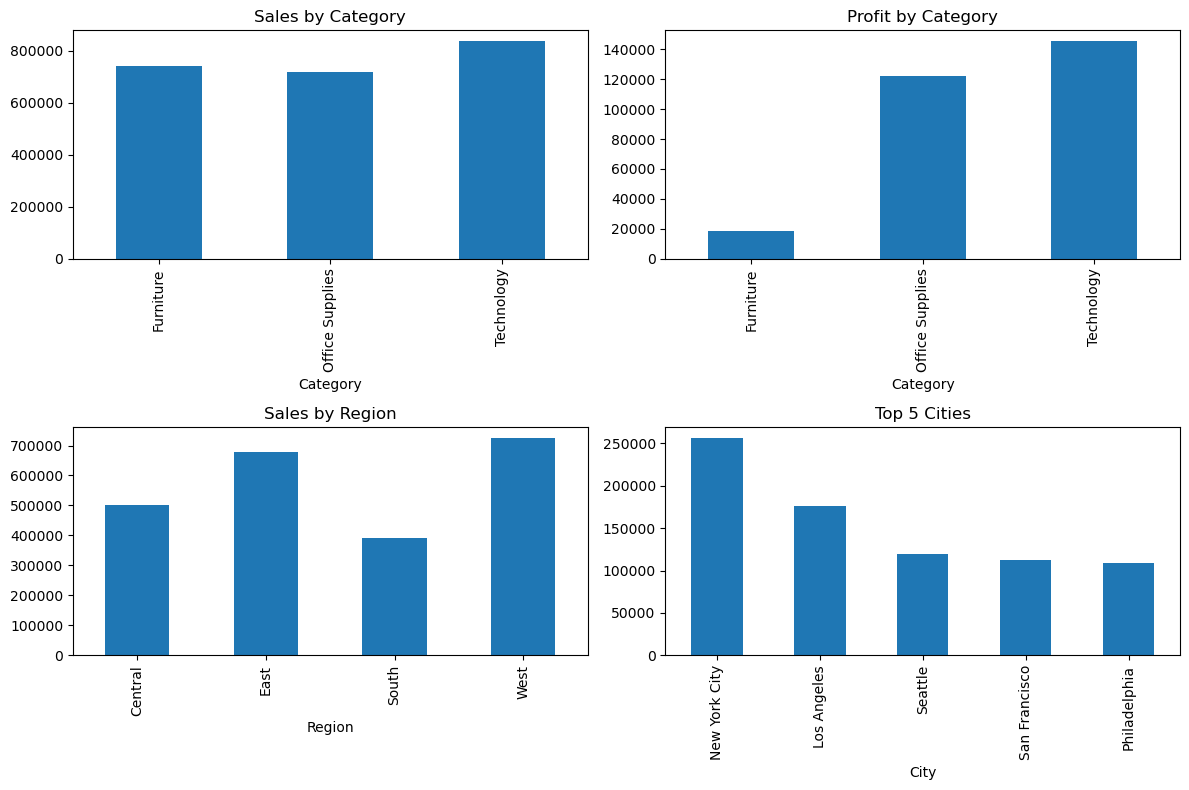

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# sales by category

plt.subplot(2, 2, 1)
category_sales.plot(kind='bar')
plt.title("Sales by Category")

# 2️⃣ Profit by Category
plt.subplot(2, 2, 2)
category_profit.plot(kind='bar')
plt.title("Profit by Category")

# 3️⃣ Sales by Region
plt.subplot(2, 2, 3)
region_sales.plot(kind='bar')
plt.title("Sales by Region")

# 4️⃣ Top Cities
plt.subplot(2, 2, 4)
top_cities.sort_values(ascending=False).head().plot(kind='bar')
plt.title("Top 5 Cities")

plt.tight_layout()
plt.show()

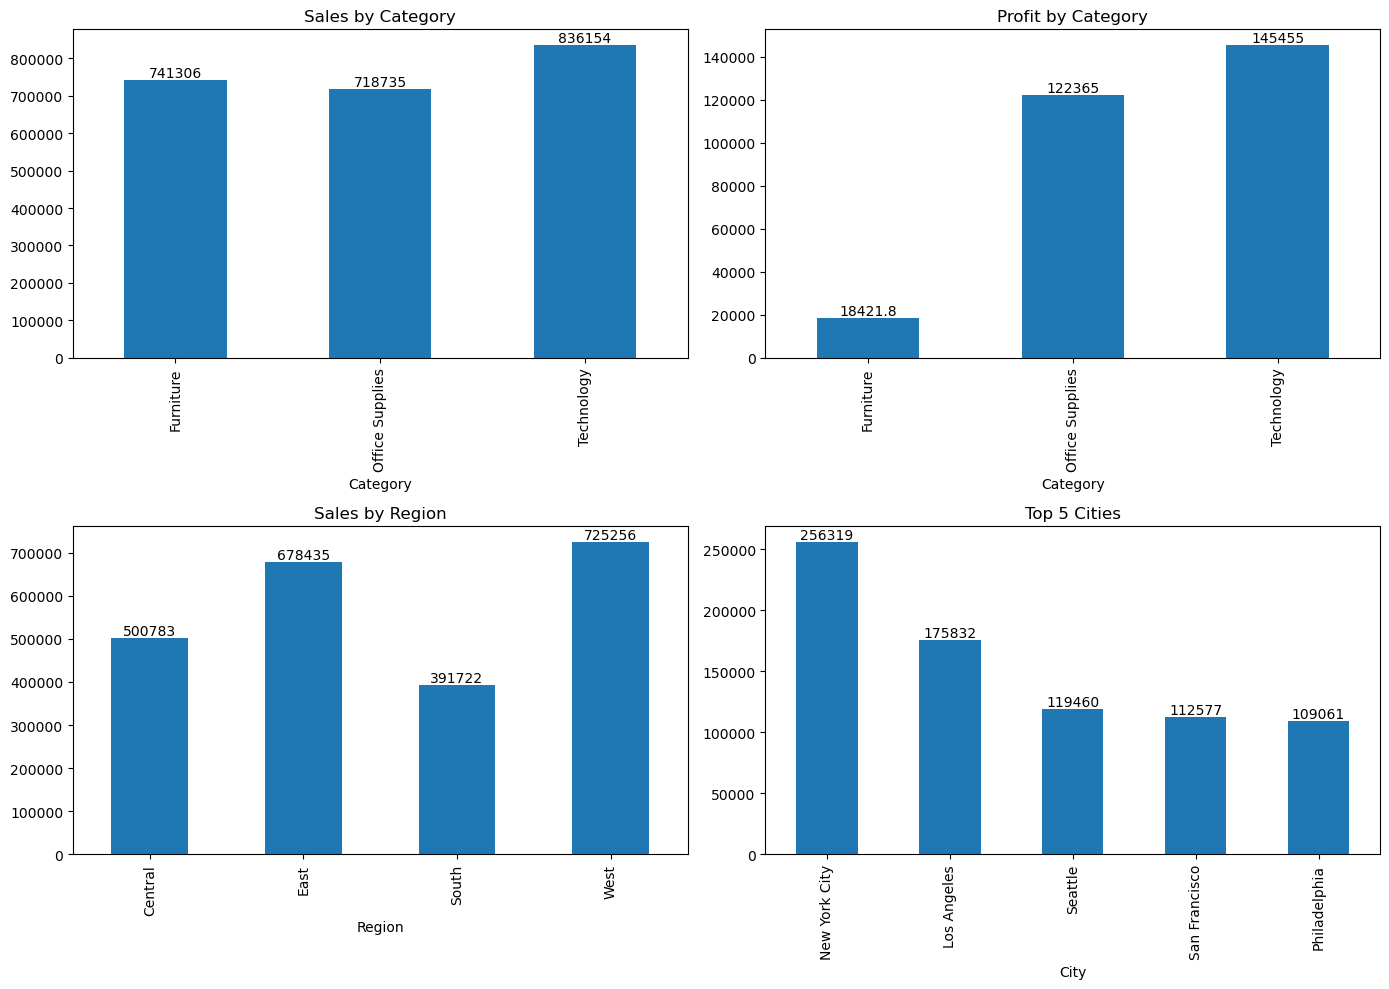

In [52]:
plt.figure(figsize=(14, 10))

# 1️⃣ Sales by Category
plt.subplot(2, 2, 1)
ax1 = category_sales.plot(kind='bar')
plt.title("Sales by Category")
for i in ax1.containers:
    ax1.bar_label(i)

# 2️⃣ Profit by Category
plt.subplot(2, 2, 2)
ax2 = category_profit.plot(kind='bar')
plt.title("Profit by Category")
for i in ax2.containers:
    ax2.bar_label(i)

# 3️⃣ Sales by Region
plt.subplot(2, 2, 3)
ax3 = region_sales.plot(kind='bar')
plt.title("Sales by Region")
for i in ax3.containers:
    ax3.bar_label(i)

# 4️⃣ Top Cities
plt.subplot(2, 2, 4)
ax4 = top_cities.sort_values(ascending=False).head().plot(kind='bar')
plt.title("Top 5 Cities")
for i in ax4.containers:
    ax4.bar_label(i)

plt.tight_layout()
plt.show()

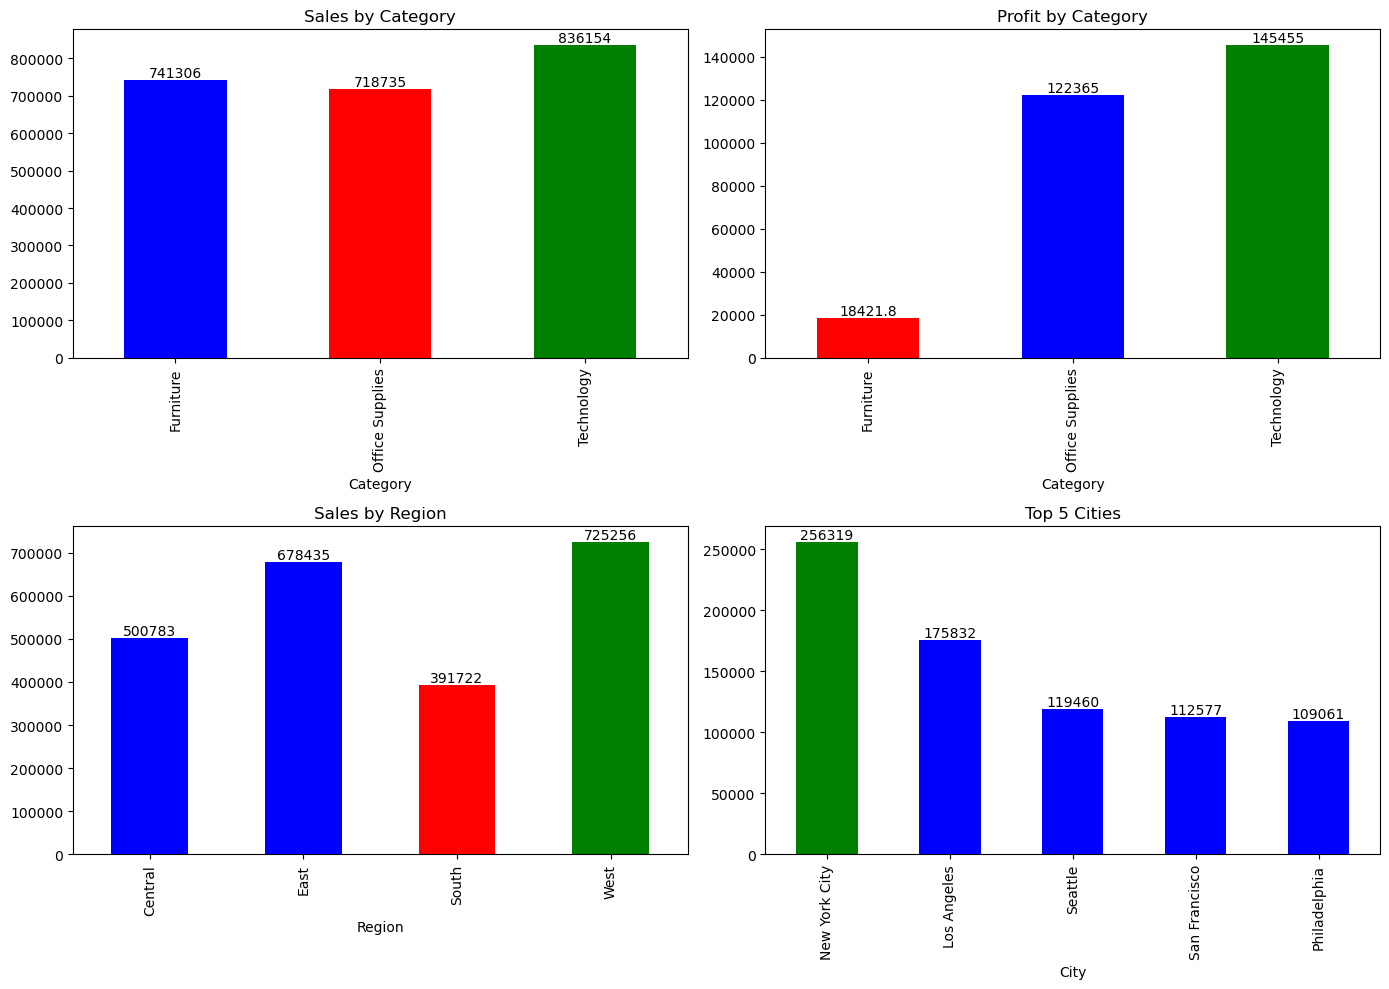

In [60]:
plt.figure(figsize=(14, 10))

# 1️⃣ Sales by Category
plt.subplot(2, 2, 1)

colors = ['red' if x == category_sales.min()
            else 'green' if x == category_sales.max()
            else 'blue' for x in category_sales]

ax1 = category_sales.plot(kind='bar', color=colors)
plt.title("Sales by Category")
for i in ax1.containers:
    ax1.bar_label(i)

# 2️⃣ Profit by Category
plt.subplot(2, 2, 2)

colors = ['red' if x == category_profit.min()
            else 'green' if x == category_profit.max()
            else 'blue' for x in category_profit]

ax2 = category_profit.plot(kind='bar', color=colors)
plt.title("Profit by Category")
for i in ax2.containers:
    ax2.bar_label(i)

# 3️⃣ Sales by Region
plt.subplot(2, 2, 3)

colors = ['red' if x == region_sales.min()
            else 'green' if x == region_sales.max()
            else 'blue' for x in region_sales]

ax3 = region_sales.plot(kind='bar',color=colors)
plt.title("Sales by Region")
for i in ax3.containers:
    ax3.bar_label(i)

# 4️⃣ Top Cities
plt.subplot(2, 2, 4)

colors = ['red' if x == top_cities.min()
            else 'green' if x == top_cities.max()
            else 'blue' for x in top_cities]

ax4 = top_cities.sort_values(ascending=False).head().plot(kind='bar',color=colors)
plt.title("Top 5 Cities")
for i in ax4.containers:
    ax4.bar_label(i)

plt.tight_layout()
plt.show()

In [61]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.
